In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


# **Model: Plain Linear Regression**

In [2]:
df = pd.read_csv("../data/buenos-aires-cleaned.csv")
df.head()

,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,Constitución
4,90000.0,50.0,-34.610610,-58.412511,Once


In [3]:
df.shape

(6146, 5)

# **Splitting Data into Feature Matrix and target vector**

In [4]:
target = "price_aprox_usd"

y = df[target]
X = df.drop(columns=target)

In [5]:
y

0       129000.0
1        87000.0
2       118000.0
3        57000.0
4        90000.0
          ...   
6141    290000.0
6142    150000.0
6143     65000.0
6144     91440.0
6145     89000.0
Name: price_aprox_usd, Length: 6146, dtype: float64

In [6]:
X.head()

,surface_covered_in_m2,lat,lon,neighborhood
0,70.0,-34.584651,-58.454693,Chacarita
1,42.0,-34.638979,-58.500115,Villa Luro
2,54.0,-34.615847,-58.459957,Caballito
3,42.0,-34.625222,-58.382382,Constitución
4,50.0,-34.610610,-58.412511,Once


# **Splitting into Training and Testing set**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Baseline**

In [8]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)
print("Mean apt price:", round(y_mean, 2))
print("Baseline MAE:", round(baseline_mae, 2))

Mean apt price: 134937.36
Baseline MAE: 45319.09


# **Build Model**

In [9]:
categorical_cols = ["neighborhood"]
numeric_cols = ["surface_covered_in_m2", "lat", "lon"]

# neighborhood gets one-hot encoded, lat/lon get imputed (some rows are missing coords)
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", SimpleImputer(strategy="mean"), numeric_cols),
])


In [10]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("linearregression", LinearRegression())
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

# **Evaluate**

In [11]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Train MAE:", round(mean_absolute_error(y_train, y_pred_train), 2))
print("Test MAE:", round(mean_absolute_error(y_test, y_pred_test), 2))
print("Train R2:", round(r2_score(y_train, y_pred_train), 3))
print("Test R2:", round(r2_score(y_test, y_pred_test), 3))

Train MAE: 24218.91
Test MAE: 25206.39
Train R2: 0.686
Test R2: 0.652


# **Communicate Results**

In [12]:
cat_features = model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_features = list(cat_features) + numeric_cols
coefs = model.named_steps["linearregression"].coef_

coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": coefs
}).sort_values(by="coefficient", key=abs, ascending=False)

coef_df.head(10)

,feature,coefficient
58,lat,322008.866980
59,lon,195183.633097
34,neighborhood_Puerto Madero,112164.228017
19,neighborhood_Las Cañitas,66498.987409
53,neighborhood_Villa Soldati,-47339.345292
7,neighborhood_Boca,-46993.927276
47,neighborhood_Villa Lugano,-46408.216013
35,neighborhood_Recoleta,41361.547639
25,neighborhood_Once,-36779.996183
26,neighborhood_Palermo,35580.911978


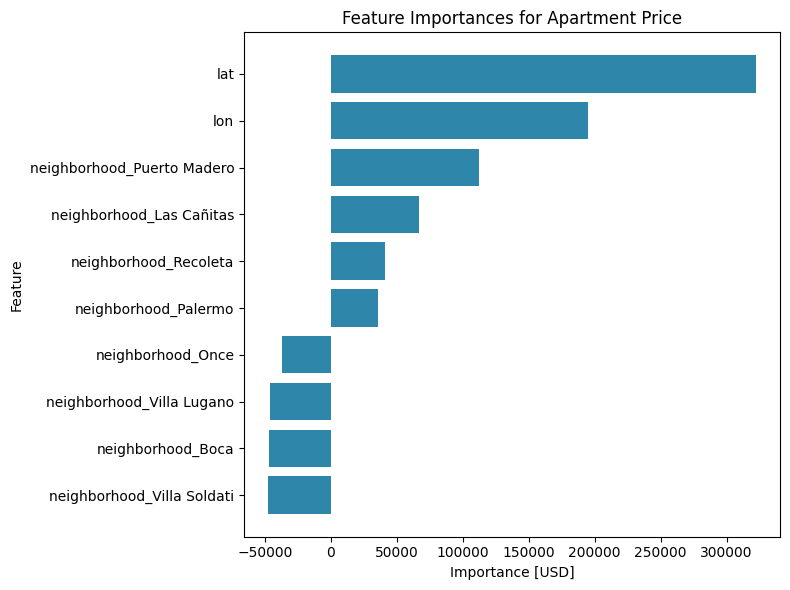

In [13]:
top10 = coef_df.head(10).sort_values(by="coefficient")
plt.figure(figsize=(8,6))
plt.barh(top10["feature"], top10["coefficient"], color="#2E86AB")
plt.xlabel("Importance [USD]")
plt.ylabel("Feature")
plt.title("Feature Importances for Apartment Price")
plt.tight_layout()
plt.savefig("../images/2_model_linear_regression_coefficients.png", dpi=150)
plt.show()


In [14]:
# saving test MAE so the comparison notebook can pull it in later
with open("../data/2_model_linear_regression_results.txt", "w") as f:
    f.write(f"{mean_absolute_error(y_test, y_pred_test)}")
